In [1]:
from itertools import product
from sklearn.model_selection import TimeSeriesSplit

PARAM_GRID = {"h": [32, 64], "lr": [1e-3, 5e-4], "batch_size": [8, 16]}
N_SPLITS   = 3

In [2]:
import os
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120})
torch.manual_seed(42); np.random.seed(42)

DATA_PATH      = os.environ.get(
    "MONETARY_DATA_PATH", os.path.join("..", "data", "Monetary_transmission_data_III.xlsx")
)
FEATURES       = ["CPI", "EXR", "M2b", "RSV", "BRNT"]
TARGETS        = ["CPI", "EXR"]
TARGET_IDX     = [FEATURES.index(t) for t in TARGETS]   # [0, 1]

SEQ_LEN        = 12     # lookback taps (monthly)
EPOCHS         = 200
BATCH_SIZE     = 16
LR             = 1e-3
PATIENCE       = 25
FORECAST_STEPS = 12
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 4 structural-break sub-periods + full dataset
WINDOWS = {
    "W1 (2003–2008)": (None,       "2008-05"),
    "W2 (2008–2016)": ("2008-06",  "2016-09"),
    "W3 (2016–2022)": ("2016-10",  "2022-02"),
    "W4 (2022–end)":  ("2022-03",  None),
    "W5 (Full)":      (None,       None),
}

In [3]:
def load_data(path: str) -> pd.DataFrame:
    """Load raw Excel data and enforce a sorted monthly DatetimeIndex."""
    df = pd.read_excel(path, parse_dates=["DATE"])
    return df.sort_values("DATE").set_index("DATE")[FEATURES]

df_full = load_data(DATA_PATH)
print(f"Range : {df_full.index[0].date()} → {df_full.index[-1].date()}  |  {len(df_full)} months")
display(df_full.describe().round(2))

Range : 2003-01-01 → 2025-10-01  |  274 months


,CPI,EXR,M2b,RSV,BRNT
count,274.00,274.00,274.00,2.740000e+02,274.00
mean,141.84,162.40,5265020.61,5.050155e+09,72.37
std,77.50,74.81,4424350.88,2.219544e+09,25.38
min,47.28,94.51,629492.93,1.170000e+09,25.04
25%,92.44,110.15,1490140.08,2.762500e+09,54.59
50%,126.56,131.09,3574177.74,5.535000e+09,70.45
75%,162.20,181.99,7770695.08,6.895000e+09,88.97
max,325.24,363.39,15577829.63,9.940000e+09,133.59


In [10]:
def make_sequences(arr: np.ndarray):
    """
    Slide a fixed SEQ_LEN window over arr.
    X : (n_samples, SEQ_LEN, n_features)
    y : (n_samples, n_targets)  — one-step-ahead label
    """
    X = np.stack([arr[i : i + SEQ_LEN] for i in range(len(arr) - SEQ_LEN)])
    y = arr[SEQ_LEN:, TARGET_IDX]
    return X.astype(np.float32), y.astype(np.float32)


def prepare_window(df_win: pd.DataFrame, test_ratio: float = 0.2):
    """
    Fit scaler on train partition only, create sequences, return device tensors.
    Returns: X_tr, y_tr, X_te, y_te, scaler, test_dates
    """
    n     = len(df_win)
    split = max(int(n * (1 - test_ratio)), SEQ_LEN + 2)

    scaler = StandardScaler().fit(df_win.values[:split])
    scaled = np.vstack([
        scaler.transform(df_win.values[:split]),
        scaler.transform(df_win.values[split:]),
    ])
    X, y = make_sequences(scaled)
    n_tr = split - SEQ_LEN
    test_dates = df_win.index[SEQ_LEN + n_tr:]

    def _t(a): return torch.tensor(a, device=DEVICE)
    return _t(X[:n_tr]), _t(y[:n_tr]), _t(X[n_tr:]), _t(y[n_tr:]), scaler, test_dates

In [11]:
class _TDNNBlock(nn.Module):
    """
    Single TDNN layer: Conv1D with same-length output (dilation-aware padding),
    shared weights across the time axis → BatchNorm → ReLU → Dropout.
    """
    def __init__(self, in_ch: int, out_ch: int, kernel: int, dilation: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel,
                      dilation=dilation,
                      padding=dilation * (kernel - 1) // 2),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

    def forward(self, x): return self.net(x)


class TDNN(nn.Module):
    """
    Stacked dilated TDNN.
    Dilations (1 → 2 → 4 → 1) aggregate temporal context up to ~17 steps;
    each layer re-uses the same kernels (weight sharing) across the timeline.
    AdaptiveAvgPool aggregates frame-level maps into a single sequence vector.

    Input  : (batch, T, n_features)
    Output : (batch, n_targets)
    """
    def __init__(self, n_feat: int, n_out: int, h: int = 64):
        super().__init__()
        self.encoder = nn.Sequential(
            _TDNNBlock(n_feat,  h,     3, 1),
            _TDNNBlock(h,       h * 2, 3, 2),
            _TDNNBlock(h * 2,   h * 2, 3, 4),
            _TDNNBlock(h * 2,   h,     3, 1),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)   # pool time dimension
        self.head = nn.Linear(h, n_out)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # (B, T, F) → (B, F, T) for Conv1d; pool → squeeze → linear
        return self.head(self.pool(self.encoder(x.permute(0, 2, 1))).squeeze(-1))

In [12]:
def _train_epoch(model, loader, opt, crit) -> float:
    model.train()
    total = 0.0
    for xb, yb in loader:
        opt.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward()
        opt.step()
        total += loss.item() * len(xb)
    return total / len(loader.dataset)


@torch.no_grad()
def _val_loss(model, X, y, crit) -> float:
    model.eval()
    return crit(model(X), y).item()


def fit(model, X_tr, y_tr, X_val, y_val, lr: float = LR, batch_size: int = BATCH_SIZE) -> dict:
    """Adam + ReduceLROnPlateau + early stopping; restores best-val weights."""
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size, shuffle=True)
    opt    = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    crit   = nn.MSELoss()
    sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=10, factor=0.5)

    best_val, no_imp, best_w = np.inf, 0, None
    hist = {"train": [], "val": []}

    for _ in range(EPOCHS):
        tr  = _train_epoch(model, loader, opt, crit)
        val = _val_loss(model, X_val, y_val, crit)
        sched.step(val)
        hist["train"].append(tr)
        hist["val"].append(val)

        if val < best_val:
            best_val, no_imp = val, 0
            best_w = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            no_imp += 1
            if no_imp >= PATIENCE:
                break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_w.items()})
    return hist

In [13]:
def rolling_window_validation(X: torch.Tensor, y: torch.Tensor, params: dict, n_splits: int) -> float:
    """Walk-forward validation: fit on each expanding fold, score MSE on the following block."""
    idx  = np.arange(len(X))
    tscv = TimeSeriesSplit(n_splits=min(n_splits, len(X) - 1))
    scores = []
    for train_idx, val_idx in tscv.split(idx):
        model = TDNN(X.shape[2], y.shape[1], params["h"]).to(DEVICE)
        fit(model, X[train_idx], y[train_idx], X[val_idx], y[val_idx], params["lr"], params["batch_size"])
        scores.append(_val_loss(model, X[val_idx], y[val_idx], nn.MSELoss()))
    return float(np.mean(scores))


def grid_search(X: torch.Tensor, y: torch.Tensor, grid: dict, n_splits: int) -> tuple[dict, float]:
    """Exhaustively score every hyperparameter combination via rolling-window validation."""
    keys = list(grid.keys())
    best_score, best_params = np.inf, None
    for combo in product(*grid.values()):
        params = dict(zip(keys, combo))
        score = rolling_window_validation(X, y, params, n_splits)
        if score < best_score:
            best_score, best_params = score, params
    return best_params, best_score

In [14]:
def inv_scale(scaler: StandardScaler, arr: np.ndarray) -> np.ndarray:
    """Inverse-transform target columns only; non-targets padded with zeros."""
    dummy = np.zeros((len(arr), len(FEATURES)), dtype=np.float32)
    dummy[:, TARGET_IDX] = arr
    return scaler.inverse_transform(dummy)[:, TARGET_IDX]


@torch.no_grad()
def get_predictions(model, X) -> np.ndarray:
    model.eval()
    return model(X).cpu().numpy()


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "RMSE": [np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i])) for i in range(len(TARGETS))],
            "MAE":  [mean_absolute_error(y_true[:, i], y_pred[:, i])         for i in range(len(TARGETS))],
            "R²":   [r2_score(y_true[:, i], y_pred[:, i])                    for i in range(len(TARGETS))],
        },
        index=TARGETS,
    )

In [15]:
results = {}

for name, (start, end) in WINDOWS.items():
    df_win = df_full.loc[slice(start, end)]

    if len(df_win) < SEQ_LEN + 10:
        print(f"[{name}] skipped — {len(df_win)} obs < minimum required")
        continue

    X_tr, y_tr, X_te, y_te, scaler, test_dates = prepare_window(df_win)
    best_params, _ = grid_search(X_tr, y_tr, PARAM_GRID, N_SPLITS)

    model   = TDNN(len(FEATURES), len(TARGETS), best_params["h"]).to(DEVICE)
    history = fit(model, X_tr, y_tr, X_te, y_te, best_params["lr"], best_params["batch_size"])

    y_pred_s = get_predictions(model, X_te)
    y_true   = inv_scale(scaler, y_te.cpu().numpy())
    y_pred   = inv_scale(scaler, y_pred_s)
    mets     = compute_metrics(y_true, y_pred)

    results[name] = dict(
        history=history, y_true=y_true, y_pred=y_pred, metrics=mets,
        model=model, scaler=scaler, df_win=df_win, test_dates=test_dates, best_params=best_params,
    )
    print(f"\n{'─' * 54}\n  {name}  "
          f"({len(df_win)} obs | train={len(y_tr)} | test={len(y_te)})\n{'─' * 54}")
    display(mets.round(4))


──────────────────────────────────────────────────────
  W1 (2003–2008)  (65 obs | train=40 | test=13)
──────────────────────────────────────────────────────


,RMSE,MAE,R²
CPI,8.9941,7.8650,-1.1811
EXR,2.7521,2.5837,-0.8643



──────────────────────────────────────────────────────
  W2 (2008–2016)  (100 obs | train=68 | test=20)
──────────────────────────────────────────────────────


,RMSE,MAE,R²
CPI,2.3240,1.9748,0.4485
EXR,10.0683,8.9111,-2.7259



──────────────────────────────────────────────────────
  W3 (2016–2022)  (65 obs | train=40 | test=13)
──────────────────────────────────────────────────────


,RMSE,MAE,R²
CPI,7.1996,4.4408,0.5168
EXR,13.8351,11.1150,-36.2723



──────────────────────────────────────────────────────
  W4 (2022–end)  (44 obs | train=23 | test=9)
──────────────────────────────────────────────────────


,RMSE,MAE,R²
CPI,3.6890,3.102,-4.0705
EXR,5.0184,4.013,-3.9152



──────────────────────────────────────────────────────
  W5 (Full)  (274 obs | train=207 | test=55)
──────────────────────────────────────────────────────


,RMSE,MAE,R²
CPI,55.0373,48.1173,-0.2115
EXR,56.2680,40.0799,-0.1338


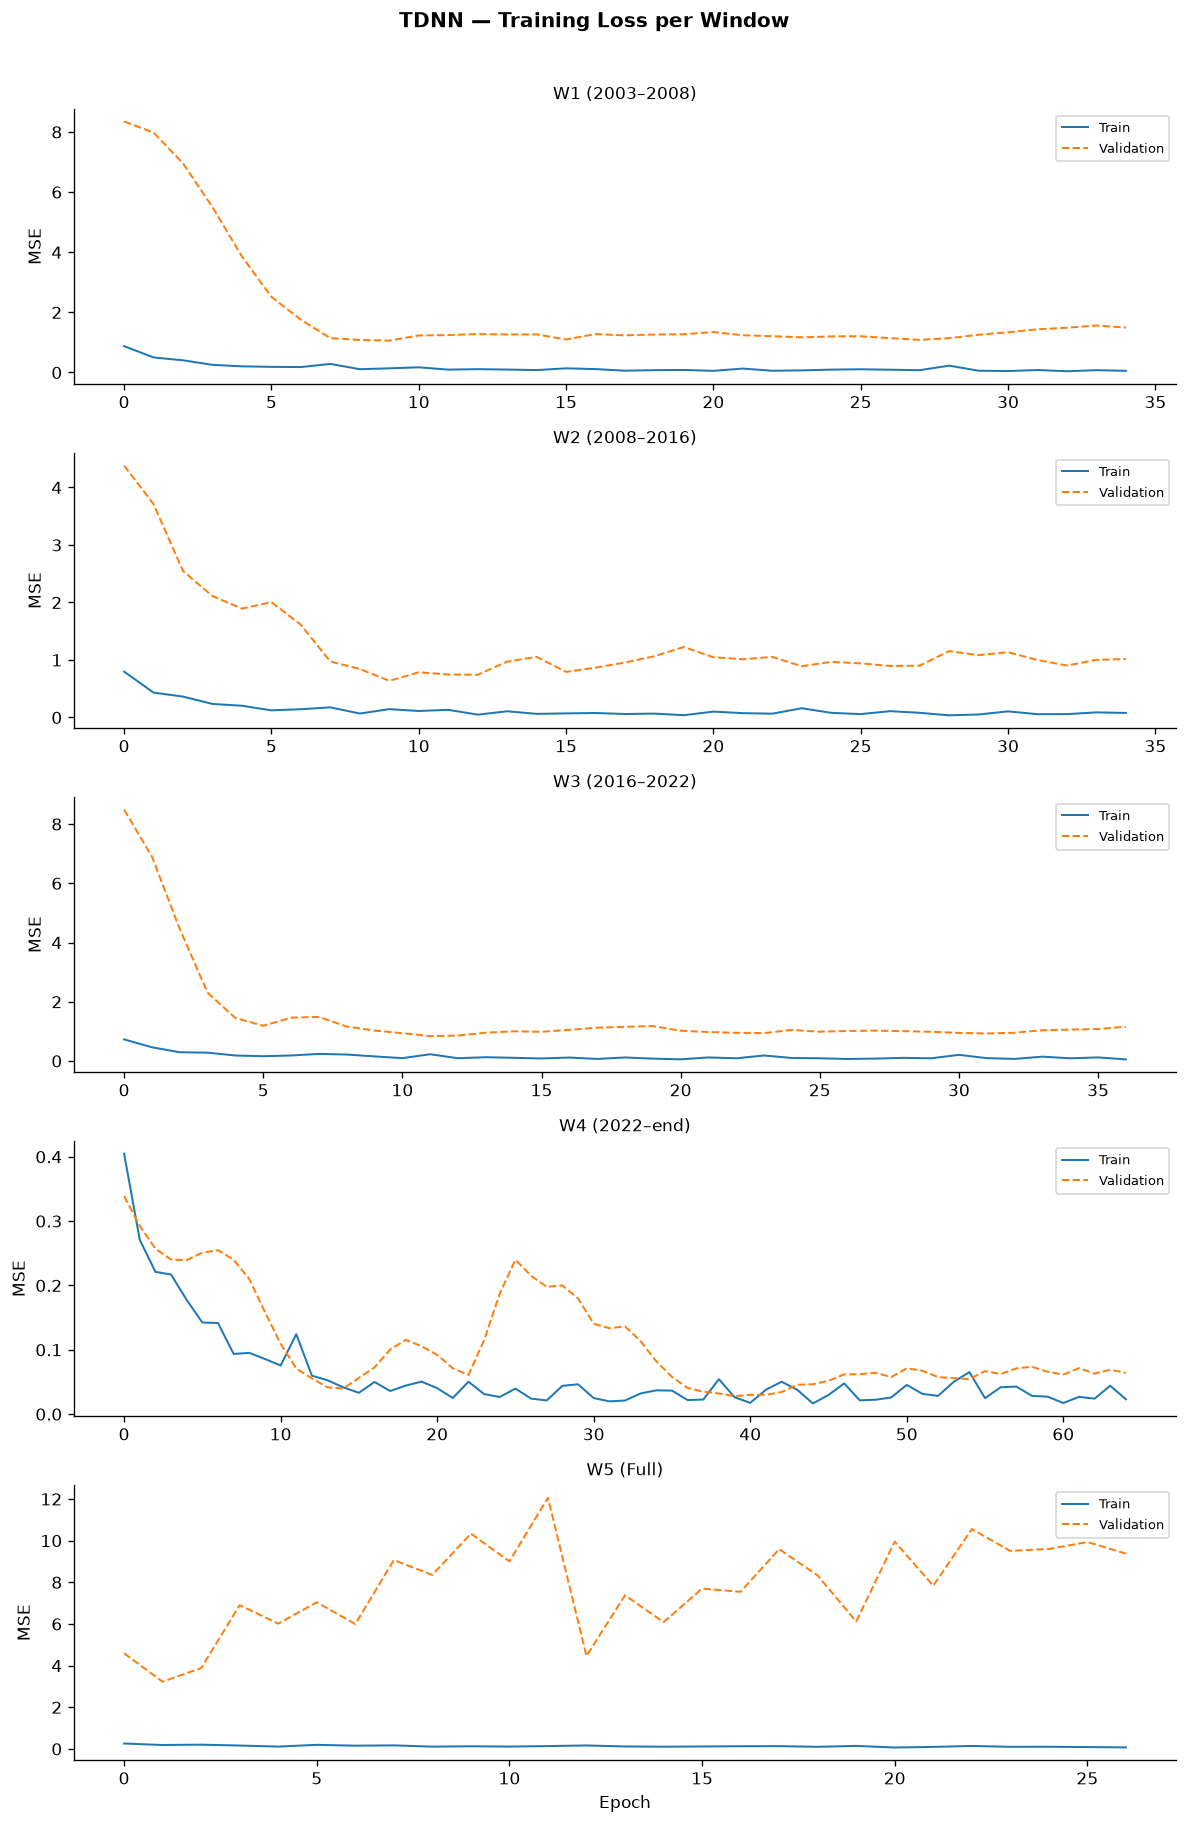

In [16]:
n    = len(results)
fig, axes = plt.subplots(n, 1, figsize=(10, 3 * n))
axes = np.atleast_1d(axes)

for ax, (name, res) in zip(axes, results.items()):
    h = res["history"]
    ax.plot(h["train"], lw=1.2, label="Train")
    ax.plot(h["val"],   lw=1.2, ls="--", label="Validation")
    ax.set_title(name, fontsize=10)
    ax.set_ylabel("MSE")
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Epoch")
plt.suptitle("TDNN — Training Loss per Window", fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

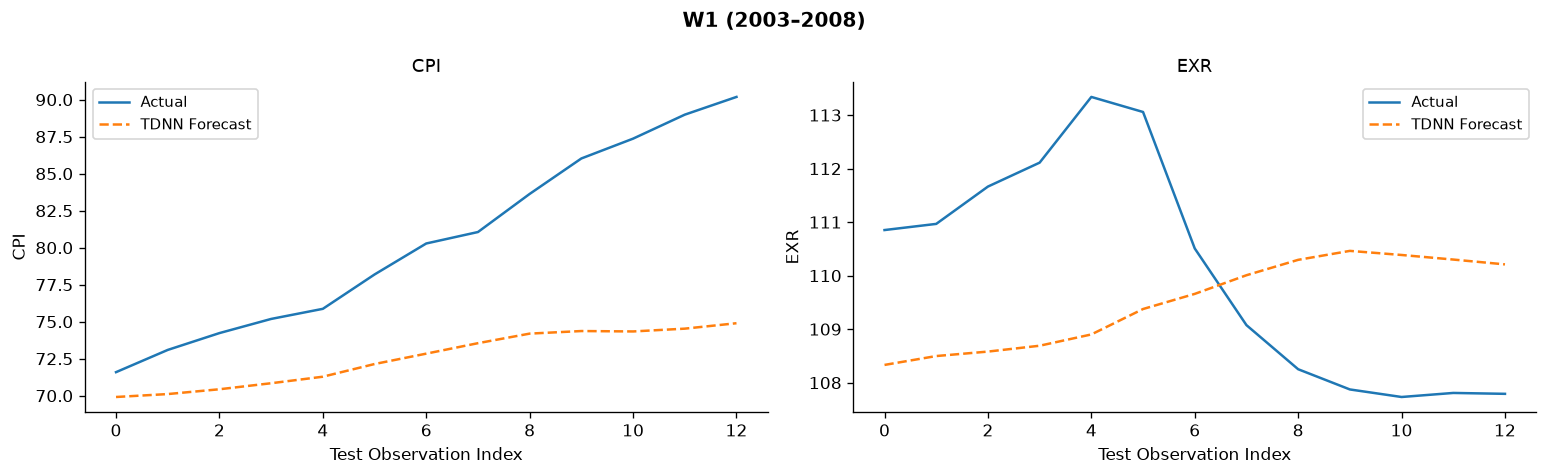

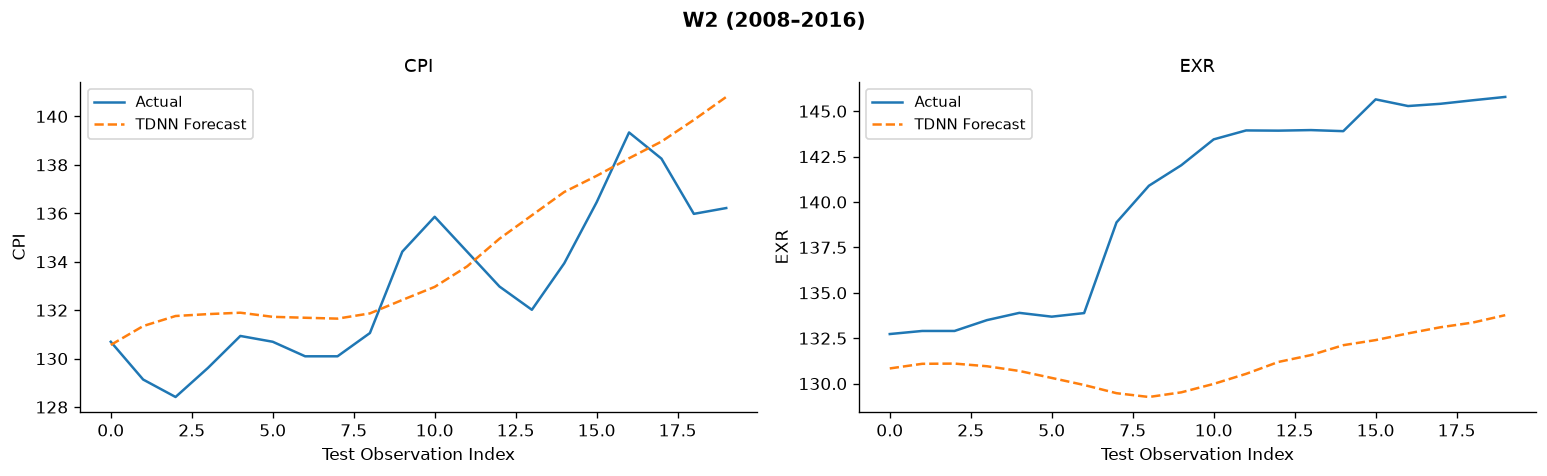

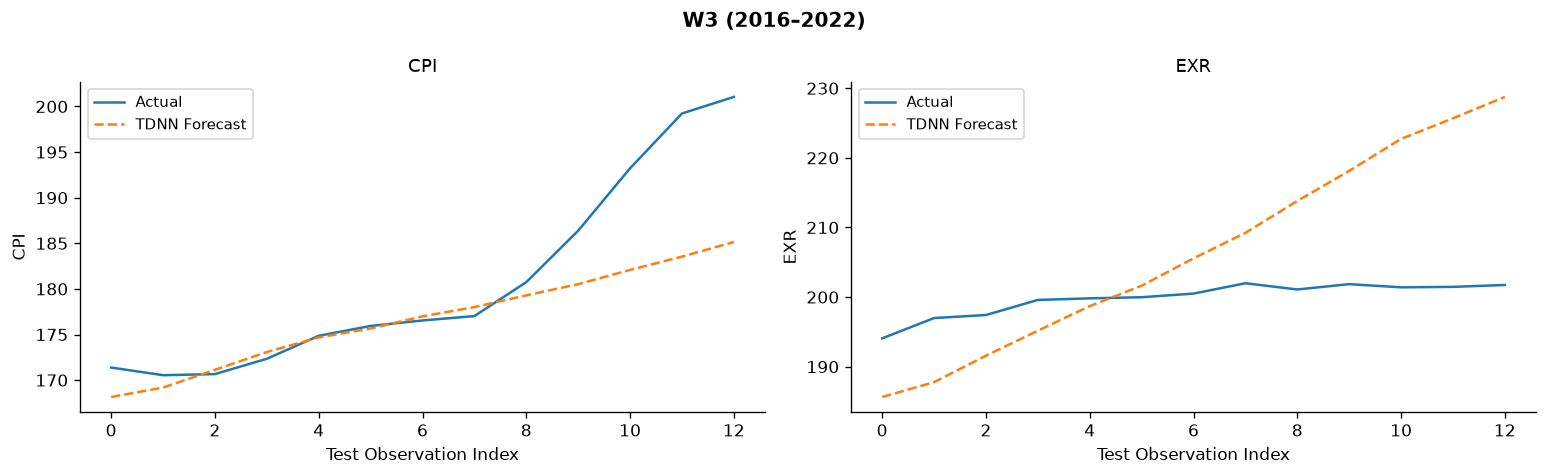

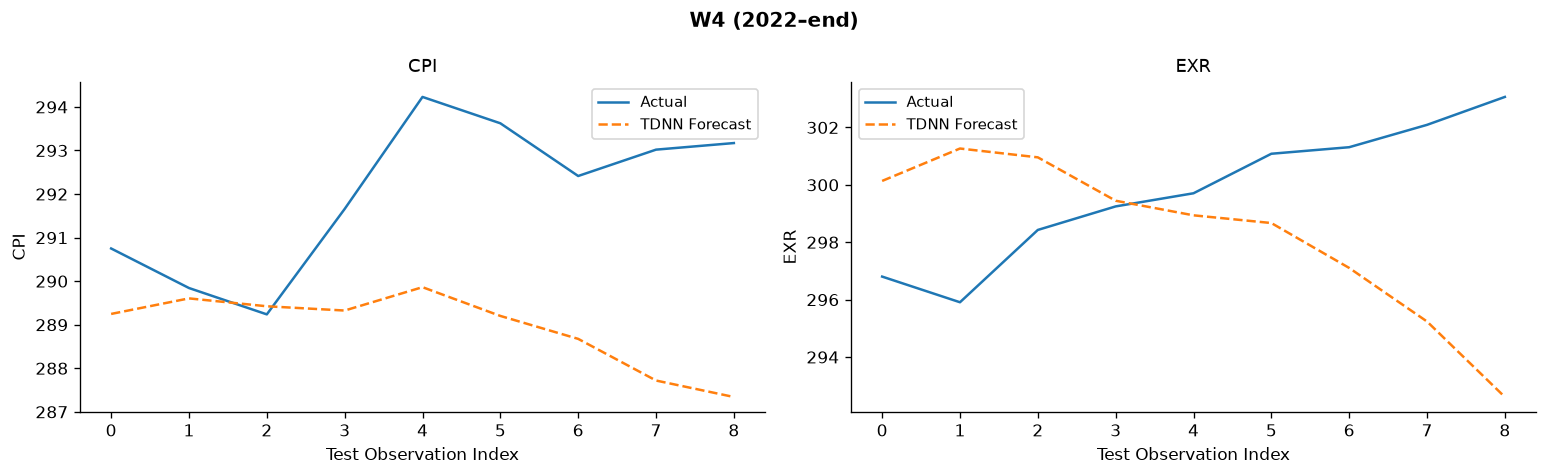

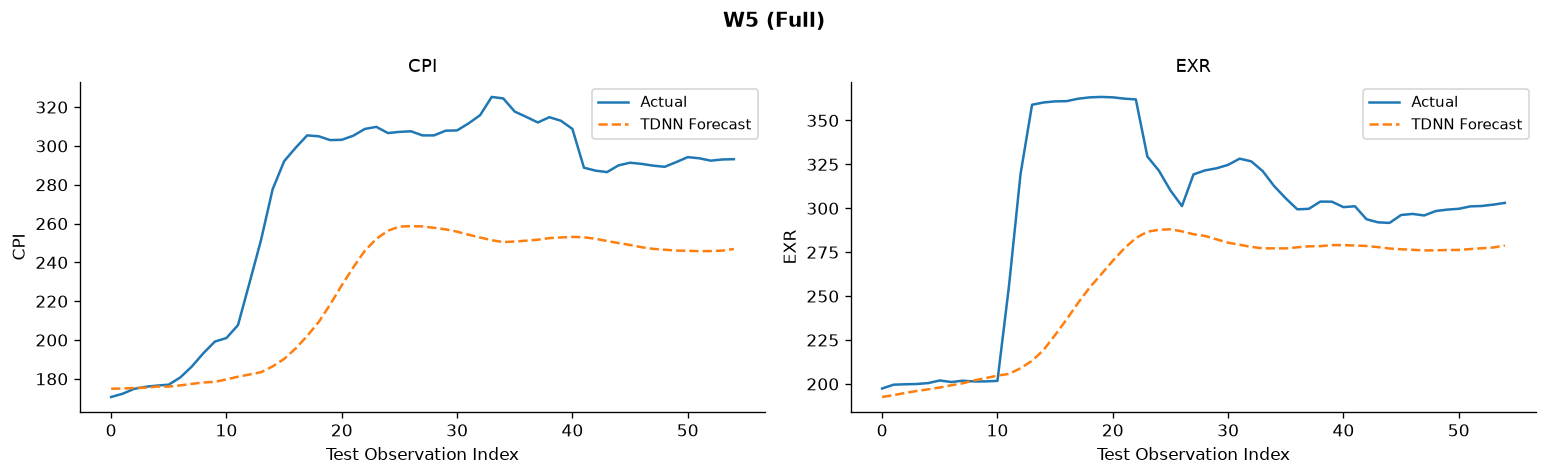

In [17]:
for name, res in results.items():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for i, (ax, tgt) in enumerate(zip(axes, TARGETS)):
        ax.plot(res["y_true"][:, i], lw=1.5, label="Actual")
        ax.plot(res["y_pred"][:, i], lw=1.5, ls="--", label="TDNN Forecast")
        ax.set_title(tgt, fontsize=11)
        ax.set_xlabel("Test Observation Index")
        ax.set_ylabel(tgt)
        ax.legend(fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
    plt.suptitle(name, fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [18]:
summary = pd.concat(
    {name: res["metrics"] for name, res in results.items()},
    names=["Window", "Target"],
)
print("=== TDNN Performance Summary ===")
display(summary.round(4))

=== TDNN Performance Summary ===


RMSE      MAE       R²
Window         Target                           
W1 (2003–2008) CPI      8.9941   7.8650  -1.1811
               EXR      2.7521   2.5837  -0.8643
W2 (2008–2016) CPI      2.3240   1.9748   0.4485
               EXR     10.0683   8.9111  -2.7259
W3 (2016–2022) CPI      7.1996   4.4408   0.5168
               EXR     13.8351  11.1150 -36.2723
W4 (2022–end)  CPI      3.6890   3.1020  -4.0705
               EXR      5.0184   4.0130  -3.9152
W5 (Full)      CPI     55.0373  48.1173  -0.2115
               EXR     56.2680  40.0799  -0.1338

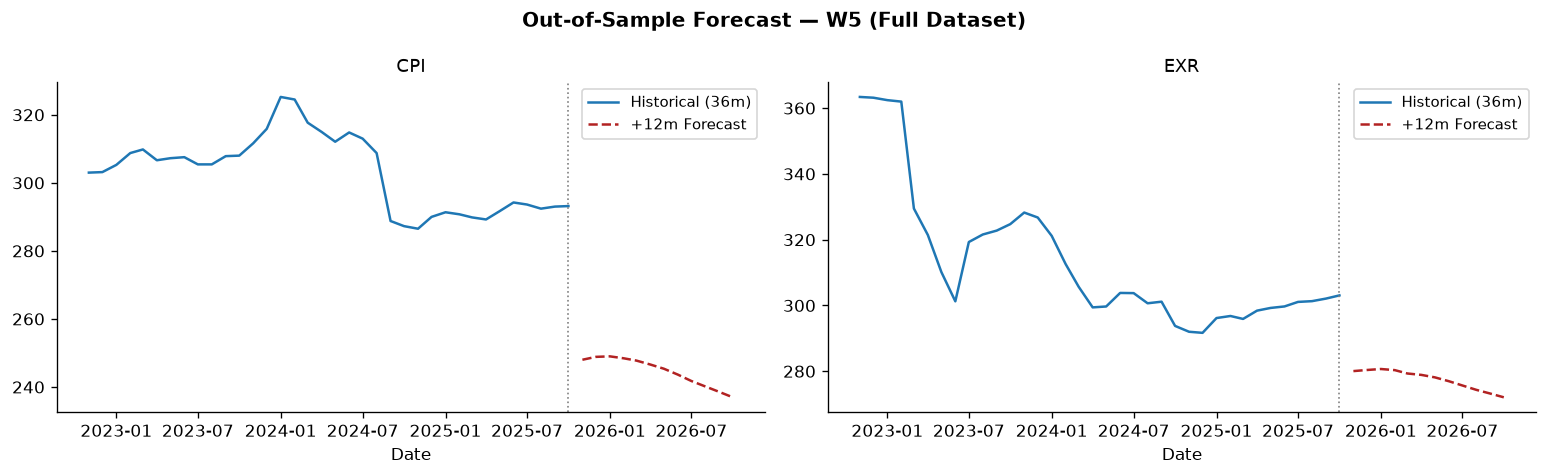


Forecast — next 12 months:


,CPI,EXR
2025-11-01,248.010406,280.052887
2025-12-01,248.860504,280.385498
2026-01-01,249.008804,280.687500
2026-02-01,248.431793,280.342407
2026-03-01,247.763596,279.321808
2026-04-01,246.602600,278.896301
2026-05-01,245.372604,278.142090
2026-06-01,243.640594,276.975006
2026-07-01,241.765594,275.679993
2026-08-01,240.159805,274.349304


In [19]:
def multistep_forecast(model, scaler, df_win, steps: int = FORECAST_STEPS) -> pd.DataFrame:
    """
    Recursive multi-step forecast.
    Exogenous vars (M2b, RSV, BRNT) are held at their last observed value;
    predicted CPI and EXR are fed back as inputs for the next step.
    """
    model.eval()
    window = scaler.transform(df_win.values[-SEQ_LEN:].astype(np.float32))
    preds  = []

    with torch.no_grad():
        for _ in range(steps):
            x    = torch.tensor(window[np.newaxis], device=DEVICE)
            pred = model(x).cpu().numpy()[0]        # (n_targets,)
            preds.append(pred)
            new_row             = window[-1].copy()
            new_row[TARGET_IDX] = pred              # feed predictions back
            window              = np.vstack([window[1:], new_row])

    idx = pd.date_range(df_win.index[-1], periods=steps + 1, freq="MS")[1:]
    return pd.DataFrame(
        inv_scale(scaler, np.array(preds, dtype=np.float32)),
        index=idx, columns=TARGETS,
    )


if "W5 (Full)" in results:
    res5   = results["W5 (Full)"]
    future = multistep_forecast(res5["model"], res5["scaler"], res5["df_win"])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for i, (ax, col) in enumerate(zip(axes, TARGETS)):
        ctx = res5["df_win"][col].iloc[-36:]         # last 3 years for context
        ax.plot(ctx.index, ctx.values, lw=1.5, label="Historical (36m)")
        ax.plot(future.index, future[col].values, lw=1.5, ls="--",
                color="firebrick", label=f"+{FORECAST_STEPS}m Forecast")
        ax.axvline(ctx.index[-1], color="gray", lw=1, ls=":")
        ax.set_title(col, fontsize=11)
        ax.set_xlabel("Date")
        ax.legend(fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)

    plt.suptitle("Out-of-Sample Forecast — W5 (Full Dataset)", fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"\nForecast — next {FORECAST_STEPS} months:")
    display(future.round(4))

In [20]:
os.makedirs("../results", exist_ok=True)
# Standardized long-format export consumed by the model-comparison pipeline.
export_rows = [
    {"window": label.split()[0], "target": tgt, "RMSE": res["metrics"].loc[tgt, "RMSE"], "MAE": res["metrics"].loc[tgt, "MAE"]}
    for label, res in results.items() for tgt in TARGETS
]
pd.DataFrame(export_rows).to_csv(f"../results/metrics_tdnn.csv", index=False)

In [21]:
pred_rows = [
    {"window": name.split()[0], "target": tgt, "date": date,
     "actual": res["y_true"][i, j], "predicted": res["y_pred"][i, j]}
    for name, res in results.items()
    for i, date in enumerate(res["test_dates"])
    for j, tgt in enumerate(TARGETS)
]
pd.DataFrame(pred_rows).to_csv("../results/predictions_tdnn.csv", index=False)